<img src="figures/observed_distribution.png" width="600"><br><br>
<img src="figures/model_pdf_comparison.png" width="600"><br><br>
<img src="figures/observed_percentiles.png" width="600"><br><br>
<img src="figures/percentile_bar_chart.png" width="600">

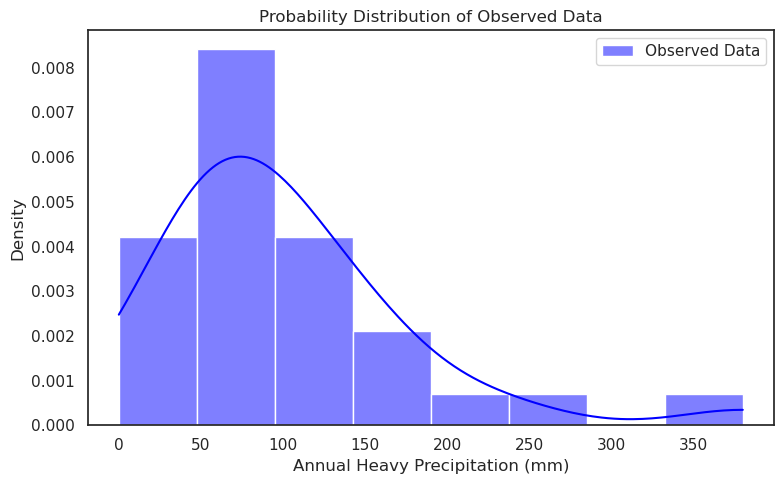

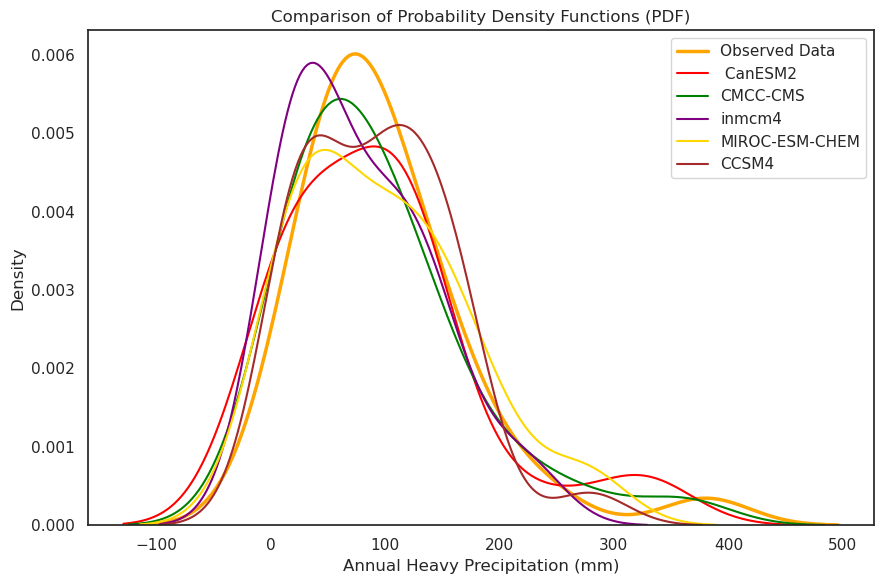

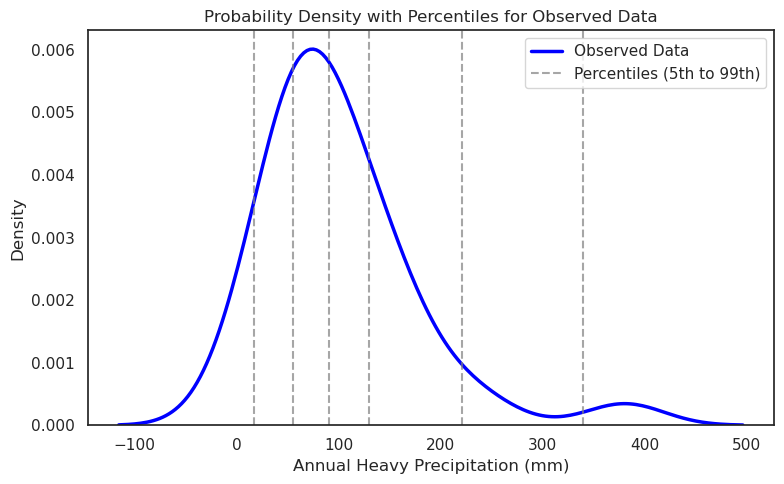

--- Percentile Comparison Table ---
Percentile  Observed   CanESM2  CMCC-CMS  inmcm4  MIROC-ESM-CHEM  CCSM4
        5%     16.39      0.00      8.42    0.00            7.83  17.00
       25%     55.35     39.03     40.80   23.58           37.25  36.95
       50%     89.95    100.80     71.95   58.10           93.05  98.55
       75%    130.00    121.75    129.88  119.02          141.18 132.65
       95%    220.34    277.49    243.00  192.09          234.86 171.59
       99%    339.43    328.50    334.66  226.14          273.77 248.68


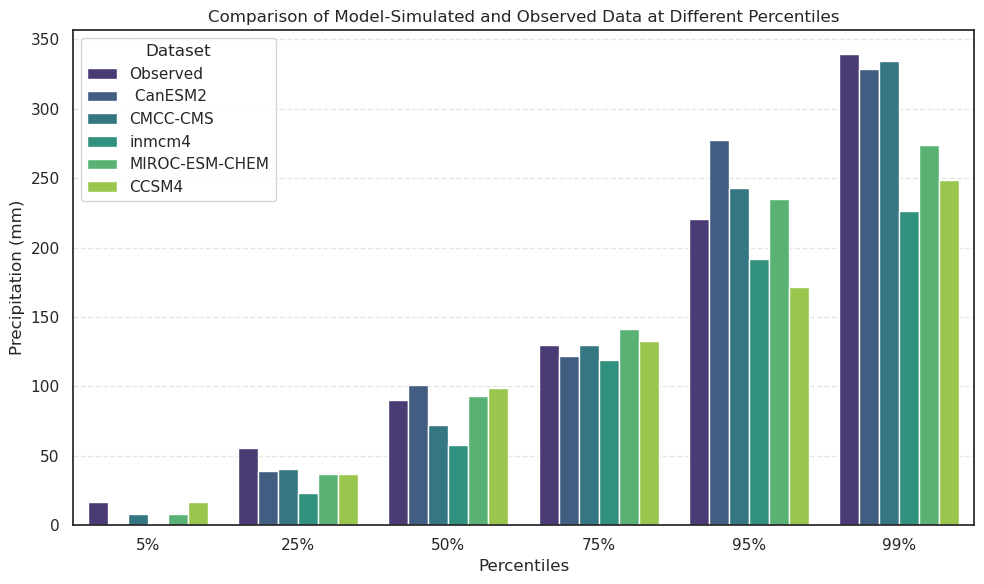


Analysis complete. Figures saved to the 'figures/' directory.


In [4]:
%pip install seaborn
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
os.makedirs('figures', exist_ok=True)
sns.set_theme(style="white")
# Load Data
df = pd.read_csv('R95p_Uncertainty_R-02.csv')
data = df.drop(columns=[df.columns[0]])
observed_col = data.columns[0]
model_cols = data.columns[1:]
percentiles_list = [5, 25, 50, 75, 95, 99]
# Task 1: Probability Distribution of Observed Data
plt.figure(figsize=(8, 5))
sns.histplot(
    data[observed_col],
    kde=True,
    stat="density",
    color="blue",
    label="Observed Data",
)
plt.title("Probability Distribution of Observed Data")
plt.xlabel("Annual Heavy Precipitation (mm)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("figures/observed_distribution.png", dpi=300)
plt.show()
# Task 2: Overlay PDFs of Climate Models
plt.figure(figsize=(9, 6))
sns.kdeplot(
    data[observed_col], label="Observed Data", linewidth=2.5, color="orange"
)
colors = ["red", "green", "purple", "gold", "brown"]
for col, color in zip(model_cols, colors):
  sns.kdeplot(data[col], label=col, linewidth=1.5, color=color)
plt.title("Comparison of Probability Density Functions (PDF)")
plt.xlabel("Annual Heavy Precipitation (mm)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("figures/model_pdf_comparison.png", dpi=300)
plt.show()
# Task 3: Draw Vertical Lines at Percentiles for Observed Data
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data[observed_col], color="blue", linewidth=2.5, label="Observed Data"
)
obs_percentiles = np.percentile(data[observed_col].dropna(), percentiles_list)
for p, val in zip(percentiles_list, obs_percentiles):
  plt.axvline(x=val, color="gray", linestyle="--", alpha=0.7)
plt.title("Probability Density with Percentiles for Observed Data")
plt.xlabel("Annual Heavy Precipitation (mm)")
plt.ylabel("Density")
plt.legend(["Observed Data", "Percentiles (5th to 99th)"])
plt.tight_layout()
plt.savefig("figures/observed_percentiles.png", dpi=300)
plt.show()
# Task 4: Compare Model-Simulated Data with Observed Data
percentile_df = pd.DataFrame(
    {"Percentile": [f"{p}%" for p in percentiles_list]}
)
for col in data.columns:
  percentile_df[col] = np.percentile(data[col].dropna(), percentiles_list)
print("--- Percentile Comparison Table ---")
print(percentile_df.round(2).to_string(index=False))
df_melted = percentile_df.melt(
    id_vars=["Percentile"],
    var_name="Dataset",
    value_name="Precipitation (mm)",
)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melted,
    x="Percentile",
    y="Precipitation (mm)",
    hue="Dataset",
    palette="viridis",
)
plt.title(
    "Comparison of Model-Simulated and Observed Data at Different Percentiles"
)
plt.xlabel("Percentiles")
plt.ylabel("Precipitation (mm)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(title="Dataset")
plt.tight_layout()
plt.savefig("figures/percentile_bar_chart.png", dpi=300)
plt.show()
print("\nAnalysis complete. Figures saved to the 'figures/' directory.")